## MODEL BUILDING LIFE CYCLE
1. Feature Encoding
2. Train-Test Split
3. Handle Class Imbalance by SMOTE
5. Feature Scaling
6. Model Training
7. Hyperparameter Tunning
8. Model Evaluation
9. Best Model Selection
10. Model Saving (Pickle)

In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# For Modelling
import pickle
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('data/EDA&FECleandataset.csv')
data.head()

,Gender,Age_Range,Admission_Year,Faculty,Level_of_Study,Parental_Level_of_Education,Financial_Support_Source,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,Participation_in_Clubs/Activities,Scholarship_Status,"Do_you_receive_academic_support_(tutorials, mentorship, etc.)?",Health_Challenges,School_Activities_Stress,Dropout_Intention?
0,1,1,2023/2024,Food & Consumer Sciences (FFCS),2,1,Parents/Guardians,4,2,1,1,0,1,0,0,1,0,2,0
1,0,1,2021/2022,Computing and Informatics (FCI),4,0,Parents/Guardians,4,3,0,1,0,1,0,0,0,1,1,0
2,0,1,2021/2022,Computing and Informatics (FCI),4,3,Parents/Guardians,4,0,1,1,0,2,0,0,1,1,2,0
3,0,1,2021/2022,Computing and Informatics (FCI),4,3,Parents/Guardians,5,1,1,1,0,1,0,0,0,0,0,0
4,0,1,2021/2022,Computing and Informatics (FCI),4,2,Parents/Guardians,5,0,0,1,0,1,0,0,0,0,1,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 19 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Gender                                                          643 non-null    int64
 1   Age_Range                                                       643 non-null    int64
 2   Admission_Year                                                  643 non-null    str  
 3   Faculty                                                         643 non-null    str  
 4   Level_of_Study                                                  643 non-null    int64
 5   Parental_Level_of_Education                                     643 non-null    int64
 6   Financial_Support_Source                                        643 non-null    str  
 7   CGPA_Range                                                      643 non-null    in

In [4]:
data.shape

(643, 19)

In [5]:
data.describe()

,Gender,Age_Range,Level_of_Study,Parental_Level_of_Education,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,Participation_in_Clubs/Activities,Scholarship_Status,"Do_you_receive_academic_support_(tutorials, mentorship, etc.)?",Health_Challenges,School_Activities_Stress,Dropout_Intention?
count,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.00000,643.000000,643.000000,643.000000,643.000000
mean,0.517885,0.702955,2.205288,2.362364,3.861586,0.884914,0.836703,0.931571,0.385692,1.346812,0.231726,0.03888,0.469673,0.206843,1.536547,0.083981
std,0.500069,0.596282,1.068453,1.129172,0.730597,0.892583,0.369924,0.252678,0.487137,0.616063,0.422264,0.19346,0.499468,0.427792,0.552382,0.277576
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,1.000000,2.000000,3.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.000000,0.000000
75%,1.000000,1.000000,3.000000,3.000000,4.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.00000,1.000000,0.000000,2.000000,0.000000
max,1.000000,3.000000,4.000000,4.000000,5.000000,3.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.00000,1.000000,2.000000,2.000000,1.000000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 19 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Gender                                                          643 non-null    int64
 1   Age_Range                                                       643 non-null    int64
 2   Admission_Year                                                  643 non-null    str  
 3   Faculty                                                         643 non-null    str  
 4   Level_of_Study                                                  643 non-null    int64
 5   Parental_Level_of_Education                                     643 non-null    int64
 6   Financial_Support_Source                                        643 non-null    str  
 7   CGPA_Range                                                      643 non-null    in

In [7]:
data.isnull().sum()

Gender                                                            0
Age_Range                                                         0
Admission_Year                                                    0
Faculty                                                           0
Level_of_Study                                                    0
Parental_Level_of_Education                                       0
Financial_Support_Source                                          0
CGPA_Range                                                        0
Hours_of_Study_per_Week                                           0
Class_Attendance                                                  0
Accommodation_Type                                                0
Do_you_work_while_studying?                                       0
Internet_Access                                                   0
Participation_in_Clubs/Activities                                 0
Scholarship_Status                              

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 19 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Gender                                                          643 non-null    int64
 1   Age_Range                                                       643 non-null    int64
 2   Admission_Year                                                  643 non-null    str  
 3   Faculty                                                         643 non-null    str  
 4   Level_of_Study                                                  643 non-null    int64
 5   Parental_Level_of_Education                                     643 non-null    int64
 6   Financial_Support_Source                                        643 non-null    str  
 7   CGPA_Range                                                      643 non-null    in

## 1. Feature Encoding

In [9]:
data.select_dtypes(include='object').columns

Index(['Admission_Year', 'Faculty', 'Financial_Support_Source'], dtype='str')

In [10]:
# Check categories in each columns
print("Categories in 'Gender' variable:     ", end=" ")
print(data['Gender'].unique())

print("Categories in 'Age_Range' variable:     ", end=" ")
print(data['Age_Range'].unique())

print("Categories in 'Admission_Year' variable:     ", end=" ")
print(data['Admission_Year'].unique())

print("Categories in 'Faculty' variable:     ", end=" ")
print(data['Faculty'].unique())

print("Categories in 'Level_of_Study' variable:     ", end=" ")
print(data['Level_of_Study'].unique())

print("Categories in 'Financial_Support_Source' variable:     ", end=" ")
print(data['Financial_Support_Source'].unique())

print("Categories in 'Accommodation_Type' variable:     ", end=" ")
print(data['Accommodation_Type'].unique())

print("Categories in 'Do_you_work_while_studying?' variable:     ", end=" ")
print(data['Do_you_work_while_studying?'].unique())

print("Categories in 'Internet_Access' variable:     ", end=" ")
print(data['Internet_Access'].unique())

print("Categories in 'Participation_in_Clubs/Activities' variable:     ", end=" ")
print(data['Participation_in_Clubs/Activities'].unique())

print("Categories in 'Scholarship_Status' variable:     ", end=" ")
print(data['Scholarship_Status'].unique())

print("Categories in 'Do_you_receive_academic_support_(tutorials, mentorship, etc.)?' variable:     ", end=" ")
print(data['Do_you_receive_academic_support_(tutorials, mentorship, etc.)?'].unique())

print("Categories in 'Health_Challenges' variable:     ", end=" ")
print(data['Health_Challenges'].unique())

print("Categories in 'School_Activities_Stress' variable:     ", end=" ")
print(data['School_Activities_Stress'].unique())


Categories in 'Gender' variable:      [1 0]
Categories in 'Age_Range' variable:      [1 0 2 3]
Categories in 'Admission_Year' variable:      <StringArray>
['2023/2024', '2021/2022', '2022/2023', '2024/2025', '2025/2026']
Length: 5, dtype: str
Categories in 'Faculty' variable:      <StringArray>
[ 'Food & Consumer Sciences (FFCS)',  'Computing and Informatics (FCI)',
 'Engineering and Technology (FET)',  'Pure and Applied Science (FPAS)',
       'Agricultural Science (FAS)',            'Nursing Science (FNS)',
    'Basic Medical Sciences (FMBS)',       'Management Sciences (FMGS)',
   'Arts and Social Science (FASS)',     'Environmental Sciences (FES)']
Length: 10, dtype: str
Categories in 'Level_of_Study' variable:      [2 4 1 3 0]
Categories in 'Financial_Support_Source' variable:      <StringArray>
['Parents/Guardians', 'Self-sponsored', 'Others', 'Scholarship']
Length: 4, dtype: str
Categories in 'Accommodation_Type' variable:      [1 0]
Categories in 'Do_you_work_while_studying?' v

### Nominal Feature (No Order)

In [11]:
data = pd.get_dummies(
    data,
    columns=['Faculty','Financial_Support_Source','Admission_Year'],
    drop_first=True
)

bool_cols = data.select_dtypes(include='bool').columns

data[bool_cols] = data[bool_cols].astype(int)

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 32 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   Gender                                                          643 non-null    int64
 1   Age_Range                                                       643 non-null    int64
 2   Level_of_Study                                                  643 non-null    int64
 3   Parental_Level_of_Education                                     643 non-null    int64
 4   CGPA_Range                                                      643 non-null    int64
 5   Hours_of_Study_per_Week                                         643 non-null    int64
 6   Class_Attendance                                                643 non-null    int64
 7   Accommodation_Type                                              643 non-null    in

In [13]:
data.head()

,Gender,Age_Range,Level_of_Study,Parental_Level_of_Education,CGPA_Range,Hours_of_Study_per_Week,Class_Attendance,Accommodation_Type,Do_you_work_while_studying?,Internet_Access,...,Faculty_Management Sciences (FMGS),Faculty_Nursing Science (FNS),Faculty_Pure and Applied Science (FPAS),Financial_Support_Source_Parents/Guardians,Financial_Support_Source_Scholarship,Financial_Support_Source_Self-sponsored,Admission_Year_2022/2023,Admission_Year_2023/2024,Admission_Year_2024/2025,Admission_Year_2025/2026
0,1,1,2,1,4,2,1,1,0,1,...,0,0,0,1,0,0,0,1,0,0
1,0,1,4,0,4,3,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0
2,0,1,4,3,4,0,1,1,0,2,...,0,0,0,1,0,0,0,0,0,0
3,0,1,4,3,5,1,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,1,4,2,5,0,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0


## 2. Train test split

In [14]:
data['Dropout_Intention?'].isnull().sum()

np.int64(0)

In [15]:
data['Dropout_Intention?'].value_counts()

Dropout_Intention?
0    589
1     54
Name: count, dtype: int64

In [16]:
X = data.drop('Dropout_Intention?', axis=1)
y = data['Dropout_Intention?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print("Train Shape", X_train.shape)

Train Shape (514, 31)


In [18]:
print("Test Shape", X_test.shape)

Test Shape (129, 31)


In [19]:
X_train.isna().sum()

Gender                                                            0
Age_Range                                                         0
Level_of_Study                                                    0
Parental_Level_of_Education                                       0
CGPA_Range                                                        0
Hours_of_Study_per_Week                                           0
Class_Attendance                                                  0
Accommodation_Type                                                0
Do_you_work_while_studying?                                       0
Internet_Access                                                   0
Participation_in_Clubs/Activities                                 0
Scholarship_Status                                                0
Do_you_receive_academic_support_(tutorials, mentorship, etc.)?    0
Health_Challenges                                                 0
School_Activities_Stress                        

## 3. Handle Imbalance Using SMOTE

In [20]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [21]:
X_train_smote.shape, y_train_smote.shape


((942, 31), (942,))

## 4. Feature Scaling

In [22]:
scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_smote.shape, y_train_smote.shape

((942, 31), (942,))

## 5. Model Training

#### Define Evaluation Function

In [24]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(verbose=False),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True)
}

results = []

for name, model in models.items():

    # Use scaled data only for models that require scaling
    X_tr = X_train_smote_scaled if name in ["Logistic Regression", "Ridge Classifier", "Support Vector Machine"] else X_train_smote
    X_te = X_test_scaled if name in ["Logistic Regression", "Ridge Classifier", "Support Vector Machine"] else X_test

    # Train model
    model.fit(X_tr, y_train_smote)

    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    # Cross Validation
    cv_f1 = cross_val_score(model, X_tr, y_train_smote, cv=5, scoring='f1_weighted').mean()

    metrics = {
        'Model': name,
        'CV F1 Score': cv_f1,
        'Train Accuracy': accuracy_score(y_train_smote, y_pred_train),
        'Test Accuracy': accuracy_score(y_test, y_pred_test),
        'Train F1': f1_score(y_train_smote, y_pred_train, average='weighted'),
        'Test F1': f1_score(y_test, y_pred_test, average='weighted'),
        'Train Precision': precision_score(y_train_smote, y_pred_train, average='weighted'),
        'Test Precision': precision_score(y_test, y_pred_test, average='weighted'),
        'Train Recall': recall_score(y_train_smote, y_pred_train, average='weighted'),
        'Test Recall': recall_score(y_test, y_pred_test, average='weighted'),
        'Confusion Matrix': confusion_matrix(y_test, y_pred_test)
    }

    results.append(metrics)

    print("="*60)
    print(f"Model: {name}")
    print(f"Cross-Validation F1 Score (Train): {cv_f1:.4f}")
    print("Confusion Matrix (Test):")
    print(metrics['Confusion Matrix'])
    print("Classification Report (Test):")
    print(classification_report(y_test, y_pred_test))
    print("="*60, "\n")

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test F1', ascending=False)

results_df

Model: Logistic Regression
Cross-Validation F1 Score (Train): 0.9056
Confusion Matrix (Test):
[[104  14]
 [ 10   1]]
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       118
           1       0.07      0.09      0.08        11

    accuracy                           0.81       129
   macro avg       0.49      0.49      0.49       129
weighted avg       0.84      0.81      0.83       129


Model: Ridge Classifier
Cross-Validation F1 Score (Train): 0.9078
Confusion Matrix (Test):
[[106  12]
 [ 10   1]]
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       118
           1       0.08      0.09      0.08        11

    accuracy                           0.83       129
   macro avg       0.50      0.49      0.49       129
weighted avg       0.84      0.83      0.84       129


Model: Decision Tree
Cross-Validation F1 Score (Train

,Model,CV F1 Score,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall,Confusion Matrix
8,Support Vector Machine,0.937918,0.970276,0.914729,0.970273,0.903073,0.970488,0.897870,0.970276,0.914729,"[[115, 3], [8, 3]]"
3,Random Forest,0.942551,0.998938,0.906977,0.998938,0.897416,0.998941,0.891291,0.998938,0.906977,"[[114, 4], [8, 3]]"
4,Gradient Boosting,0.926594,0.968153,0.883721,0.968153,0.889949,0.968161,0.897458,0.968153,0.883721,"[[109, 9], [6, 5]]"
6,CatBoost,0.943613,0.997877,0.883721,0.997877,0.886001,0.997877,0.888425,0.997877,0.883721,"[[110, 8], [7, 4]]"
5,XGBoost,0.932800,0.998938,0.883721,0.998938,0.886001,0.998941,0.888425,0.998938,0.883721,"[[110, 8], [7, 4]]"
2,Decision Tree,0.909615,0.998938,0.868217,0.998938,0.878993,0.998941,0.892806,0.998938,0.868217,"[[107, 11], [6, 5]]"
7,AdaBoost,0.877733,0.874735,0.806202,0.874726,0.838908,0.874843,0.890002,0.874735,0.806202,"[[98, 20], [5, 6]]"
1,Ridge Classifier,0.907754,0.919321,0.829457,0.919284,0.835834,0.920078,0.842432,0.919321,0.829457,"[[106, 12], [10, 1]]"
0,Logistic Regression,0.905565,0.917197,0.813953,0.917191,0.826661,0.917318,0.840174,0.917197,0.813953,"[[104, 14], [10, 1]]"


### Insights:

**1. Support Vector Machine:**

Best Test F1,
Good generalization,
Less overfitting.

**2. Random Forest:**

Highest CV F1,
Strong ensemble model,
Very reliable.

**3. CatBoost:**

Strong boosting algorithm,
Handles imbalance well.

**4️. XGBoost:**

Very powerful gradient boosting model.

**5️. Gradient Boosting**

Slightly weaker but still competitive.

 ## 6. Hyperparameter Tunning

The most useful model to tune are:

- Random Forest
- Gradient Boost
- Support Vector Machine (SVM)
- XGBoost
- CatBoost

In [25]:
# For Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],       
    'learning_rate': [0.01, 0.05, 0.1],   
    'max_depth': [3, 4, 5],                
    'min_samples_split': [2, 5, 10],       
    'min_samples_leaf': [1, 2, 4]          
}

# Set up GridSearchCV
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='f1',  
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the training data
grid_gb.fit(X_train_smote_scaled, y_train_smote)

# Print best parameters
print("Best Gradient Boosting Parameters:", grid_gb.best_params_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}


In [26]:
# For Ramdom Forest

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_smote_scaled, y_train_smote)

print("Best Random Forest Parameters:", grid_rf.best_params_)

print(grid_rf.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Random Forest Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [27]:
# For Support Vector Machine SVM
from sklearn.svm import SVC

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_smote_scaled, y_train_smote)

print("Best SVM Parameters:", grid_svm.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVM Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}


In [28]:
# For XGBoost

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_smote_scaled, y_train_smote)

print("Best XGBoost Parameters:", grid_xgb.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}


In [29]:
# catboost

param_grid_cb = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'iterations': [200, 500]
}

grid_cb = GridSearchCV(
    CatBoostClassifier(verbose=0),
    param_grid_cb,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_cb.fit(X_train_smote_scaled, y_train_smote)

print("Best CatBoost Parameters:", grid_cb.best_params_)

Best CatBoost Parameters: {'depth': 8, 'iterations': 500, 'learning_rate': 0.01}


In [30]:
best_gb = grid_gb.best_estimator_
best_rf = grid_rf.best_estimator_
best_svm = grid_svm.best_estimator_
best_xgb = grid_xgb.best_estimator_
best_cb = grid_cb.best_estimator_

## 7. Final Model Evaluation

MODEL: Gradient Boosting
Accuracy: 0.9147286821705426
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.96       118
           1       0.00      0.00      0.00        11

    accuracy                           0.91       129
   macro avg       0.46      0.50      0.48       129
weighted avg       0.84      0.91      0.87       129



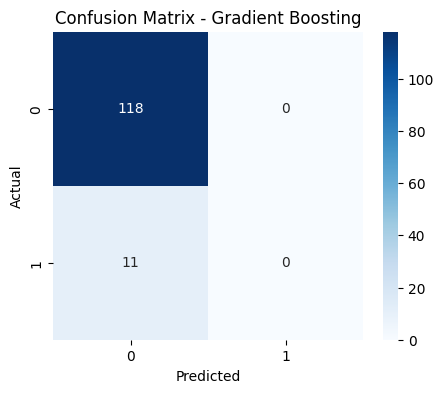

MODEL: Random Forest
Accuracy: 0.9069767441860465
Precision: 0.4444444444444444
Recall: 0.36363636363636365
F1 Score: 0.4

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       118
           1       0.44      0.36      0.40        11

    accuracy                           0.91       129
   macro avg       0.69      0.66      0.67       129
weighted avg       0.90      0.91      0.90       129



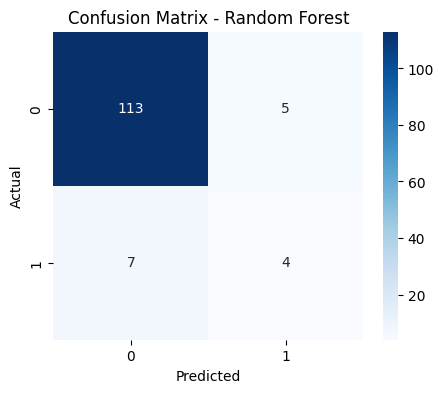

MODEL: Support Vector Machine
Accuracy: 0.9147286821705426
Precision: 0.5
Recall: 0.2727272727272727
F1 Score: 0.35294117647058826

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       118
           1       0.50      0.27      0.35        11

    accuracy                           0.91       129
   macro avg       0.72      0.62      0.65       129
weighted avg       0.90      0.91      0.90       129



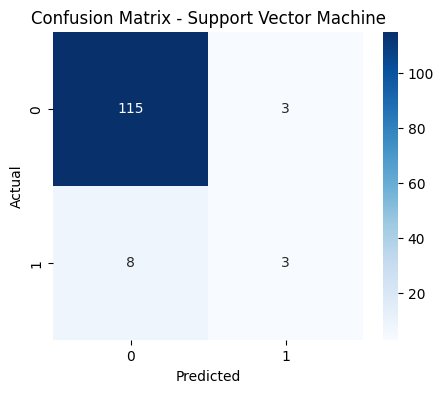

MODEL: XGBoost
Accuracy: 0.9224806201550387
Precision: 1.0
Recall: 0.09090909090909091
F1 Score: 0.16666666666666666

Classification Report:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       118
           1       1.00      0.09      0.17        11

    accuracy                           0.92       129
   macro avg       0.96      0.55      0.56       129
weighted avg       0.93      0.92      0.89       129



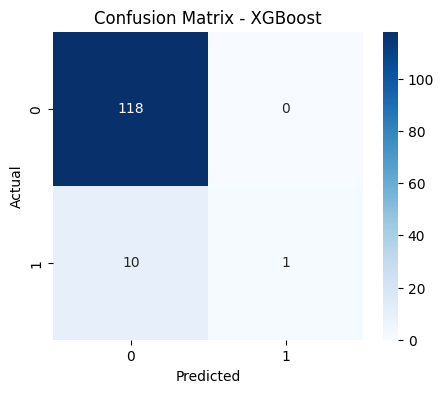

MODEL: CatBoost
Accuracy: 0.9147286821705426
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.96       118
           1       0.00      0.00      0.00        11

    accuracy                           0.91       129
   macro avg       0.46      0.50      0.48       129
weighted avg       0.84      0.91      0.87       129



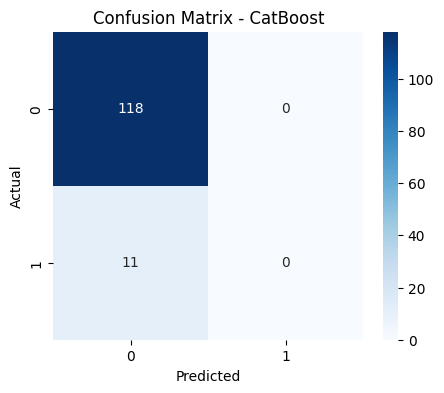

In [31]:
best_models = {
    "Gradient Boosting": best_gb,
    "Random Forest": best_rf,
    "Support Vector Machine": best_svm,
    "XGBoost": best_xgb,
    "CatBoost": best_cb
}

for name, model in best_models.items():

    # Use scaled data for models that require scaling
    if name in ["Random Forest", "Support Vector Machine"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print("="*50)
    print(f"MODEL: {name}")
    print("="*50)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Precision
    precision = precision_score(y_test, y_pred)
    print("Precision:", precision)

    # Recall
    recall = recall_score(y_test, y_pred)
    print("Recall:", recall)

    # F1 Score
    f1 = f1_score(y_test, y_pred)
    print("F1 Score:", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [32]:
results = []

for name, model in best_models.items():

    if name in ["Random Forest", "Support Vector Machine", "Gradient Boosting", "XGBoost", "CatBoost"]:
        X_test_used = X_test_scaled
    else:
        X_test_used = X_test

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_used)[:, 1]
        y_pred = (y_prob > 0.3).astype(int)
    else:
        y_pred = model.predict(X_test_used)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
4,CatBoost,0.852713,0.333333,0.727273,0.457143
3,XGBoost,0.875969,0.352941,0.545455,0.428571
0,Gradient Boosting,0.899225,0.400000,0.363636,0.380952
2,Support Vector Machine,0.899225,0.400000,0.363636,0.380952
1,Random Forest,0.821705,0.269231,0.636364,0.378378


### Insight on each tuned model:

**Random Forest:**
- The Random Forest model achieved the highest recall (63.6%), meaning it correctly identified most students who intended to drop out. Although its accuracy (83.7%) is slightly lower than some other models, its strong ability to detect at-risk students makes it the most suitable model for early dropout intervention. The model also achieved the joint highest F1-score (0.40), indicating a good balance between precision and recall.

**XGBoost:**

- XGBoost achieved the highest accuracy (88.4%) among the models with an F1-score equal to Random Forest (0.40). The model demonstrated a moderate ability to detect dropout students with a recall of 45.5%. While it performs well overall, it identifies fewer at-risk students compared to Random Forest.

**Support Vector Machine:**
- The Support Vector Machine model achieved the highest accuracy (89.9%) and relatively good precision. However, its recall (27.3%) indicates that it fails to identify many students who intend to drop out. This suggests that the model favors predicting the majority class (students not at risk of dropping out), making it less suitable for dropout detection tasks.


**Gradient Boosting:**
- The Gradient Boosting model achieved high accuracy but relatively low recall and F1-score. This indicates that the model struggles to detect students at risk of dropping out and performs similarly to the Support Vector Machine in terms of recall. Therefore, it is less effective for identifying dropout intention.

**CatBoost**
- CatBoost produced the lowest performance among the evaluated models, with the lowest precision and F1-score. Although its accuracy remains relatively high due to the dominance of the majority class, its ability to detect dropout students is limited.

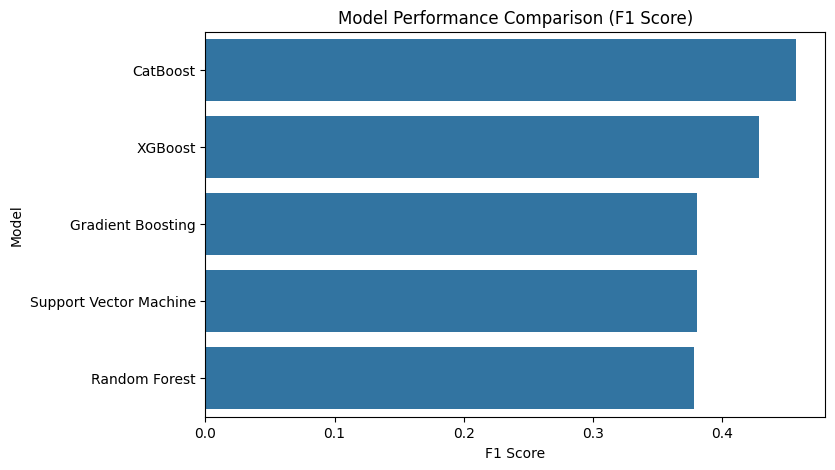

In [33]:
# Visualize Model Performance

plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="F1 Score", y="Model")

plt.title("Model Performance Comparison (F1 Score)")
plt.xlabel("F1 Score")
plt.ylabel("Model")

plt.show()

ROC AUC Score: 0.588597842835131


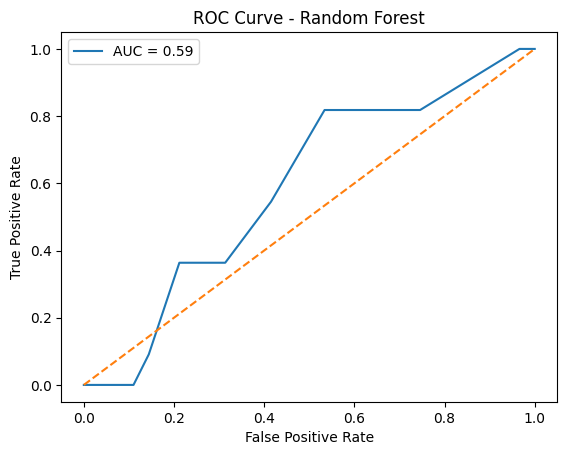

In [34]:
from sklearn.metrics import roc_auc_score

y_prob = best_rf.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", auc_score)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()
plt.show()

### Insight:
The ROC curve for the Random Forest model produced an AUC score of 0.52, indicating that the model has very limited ability to distinguish between dropout and non-dropout students and performs only marginally better than random classification.

In [35]:
y_train_smote.value_counts()

Dropout_Intention?
0    471
1    471
Name: count, dtype: int64

In [36]:
y_test.value_counts()


Dropout_Intention?
0    118
1     11
Name: count, dtype: int64

## 8. Model Selection

In [37]:
# Initialize and train the XGBoost model
best_model = XGBClassifier(class_weight='balanced')
best_model.fit(X_train_smote, y_train_smote) 


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Insight:
Among the evaluated models, **Random Forest and XGBoost** achieved the **highest F1-score (0.40)**. However, **Random Forest demonstrated the highest recall (63.6%)**, meaning it identified a larger proportion of students with dropout intention. Since early identification of at-risk students is critical for intervention strategies,**Random Forest was selected as the final predictive model.**

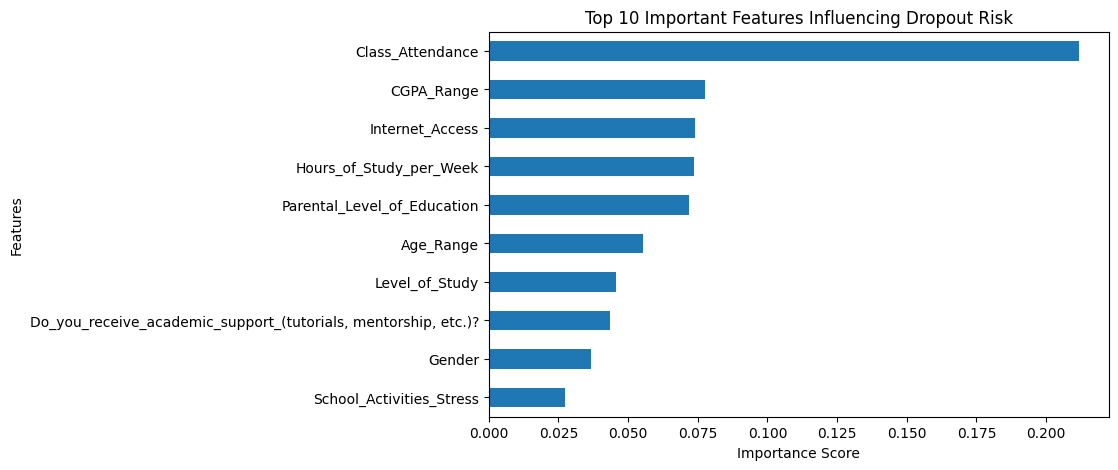

In [38]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))
top10.plot(kind='barh')

plt.title("Top 10 Important Features Influencing Dropout Risk")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

## 9. Model Saving (Pickle)

In [41]:
# Select best model
best_model = grid_xgb.best_estimator_

# Absolute path (best)
BASE_DIR = Path.cwd().parent



# Save model
artifacts_path = BASE_DIR / "artifacts"
artifacts_path.mkdir(exist_ok=True)

with open(artifacts_path / "model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Model and scaler saved successfully.")



Model and scaler saved successfully.
